# UnPaired multi-model analysis

Here we will use 10X PBMCs scRNA-seq dataset from scanpy as an example to illustrate how Garfield performs scRNA-seq clustering analysis

In [1]:
import os
import numpy as np

os.chdir('/data2/zhouwg_data/project/Garfield')
# os.chdir('/data2/zhouwg/Pytorch_study/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)

gf.__version__

'0.1.2'

In [3]:
rna = sc.read_h5ad('../Garfield_test/data/human_pbmc_10x_3k_RNA.h5ad')
# rna = sc.read_h5ad('./data/human_pbmc_10x_3k_RNA.h5ad')
rna.layers['counts'] = rna.X.copy()
rna.obs['batch'] = 'RNA'
atac = sc.read_h5ad('../Garfield_test/data/human_pbmc_10x_3k_ATAC.h5ad')
# atac = sc.read_h5ad('./data/human_pbmc_10x_3k_ATAC.h5ad')
atac.layers['counts'] = atac.X.copy()
atac.obs['batch'] = 'ATAC'

In [4]:
rna.var['gene'] = rna.var_names

In [5]:
# rna.obs['celltype'] = rna.obs['cell_type']

In [6]:
atac.obs['celltype'].value_counts()

celltype
CD14 Mono    735
CD8 Naive    339
CD4 Naive    330
Treg         256
CD4 TCM      235
B cell       199
CD8 TEM      181
CD16 Mono    106
NK            99
cDC2          64
pDC           29
MAIT          17
Name: count, dtype: int64

In [7]:
rna.obs['celltype'].value_counts()

celltype
CD14 Mono    735
CD8 Naive    339
CD4 Naive    330
Treg         256
CD4 TCM      235
B cell       199
CD8 TEM      181
CD16 Mono    106
NK            99
cDC2          64
pDC           29
MAIT          17
Name: count, dtype: int64

In [8]:
import pandas as pd
import anndata as ad

# 假设 atac_var_name 是 adata 的一个属性，已经是一个 pandas Series
atac_var_name = atac.var_names  # 假设 var_names 中存储了你需要处理的数据

# 分割每个元素
split_data = atac_var_name.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac_var_name
# 将分割后的数据转换为 DataFrame 并命名列
split_data.columns = ['chr', 'start', 'end']

# 将处理后的 DataFrame 存储到 adata.var 中
atac.var[['chr', 'start', 'end']] = split_data

In [9]:
mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2590 × 134920
  var:	'gene'
  2 modalities
    rna:	2590 x 36601
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
      var:	'gene'
      layers:	'counts'
    atac:	2590 x 98319
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch'
      var:	'gene', 'chr', 'start', 'end'
      layers:	'counts'

In [10]:
# set workdir
workdir = 'result_garfield_multiome_10xpbmc3k_Unpaired' # result_garfield_multiome_10xpbmc3k_Unpaired
gf.settings.set_workdir(workdir)

Saving results in: result_garfield_multiome_10xpbmc3k_Unpaired


In [11]:
gf.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [12]:
# make plots prettier
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [15]:
### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='multiome_10xpbmc3k',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=mdata,  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='multi-modal',
    data_type='UnPaired',  # Paired
    genome='hg19',
    sample_col='batch',  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    rna_n_top_features=3000,
    atac_n_top_features=10000,  # INT     Number of top genes to be selected.       Default is 2000.
    metric='euclidean',  # STR     Metric for clustering.                   Default is `correlation`. euclidean

    ## Model options
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20,
    test_split=0.2,
    val_split=0.2,
    used_edge_weight=True,
    used_recon_exp=True,
    used_DSBN=False,
    used_mmd=True,
    batch_size=128,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=200,  # INT       Number of epochs.       Default is 100.
    mmd_temperature=1.0,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    monitor_only_val_losses=False,
    learning_rate=0.001
)
dict_config = gf.settings.set_gf_params(user_config)

In [16]:
## start training
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...



Processing...


Convert peak to gene activity matrix, please wait.
`genome` parameter should be set correctly
Choose from {‘hg19’, ‘hg38’, ‘mm9’, ‘mm10’}
Gene scores are being calculated for the first time
`use_precomputed` has been ignored


***** WARNING: File /tmp/pybedtools.0j8eg7kb.tmp has inconsistent naming convention for record:
KI270727.1	52086	52980	98269

***** WARNING: File /tmp/pybedtools.0j8eg7kb.tmp has inconsistent naming convention for record:
KI270727.1	52086	52980	98269

***** WARNING: File /tmp/pybedtools.0j8eg7kb.tmp has inconsistent naming convention for record:
KI270727.1	52086	52980	98269

***** WARNING: File /tmp/pybedtools.0j8eg7kb.tmp has inconsistent naming convention for record:
KI270727.1	52086	52980	98269



Processing: 0.0%
Processing: 20.0%
Processing: 40.0%
Processing: 60.0%
Processing: 80.0%
There are 13933 common genes in RNA and ATAC datasets
Data preprocessing and graph construction finished
Data files exist, loading...


Done!


Finished loading.

Model training.

 |--------------------| 3.5%  - epoch_total_loss: 1881.1129913330 - epoch_vgae_loss: 33.8119907379 - epoch_instance_loss: 7.7109336853 - epoch_cluster_loss: 3.4550249577 - epoch_recon_loss: 274.4140777588 - epoch_regu_loss: 3.5529546738 - epoch_mmd_loss: 1558.1679878235 - val_total_loss: 2656.6916503906 - val_vgae_loss: 34.9050216675 - val_instance_loss: 7.4157271385 - val_cluster_loss: 3.3948326111 - val_recon_loss: 252.0786437988 - val_regu_loss: 3.5498747826 - val_mmd_loss: 2355.3476562500 - test_roc_auc: 0.5000000000 - test_precision: 0.500000000000000000581818656716

EarlyStopping: run 7 epoch
Model is saved under result_garfield_multiome_10xpbmc3k_Unpaired/checkpoint/model.pt.


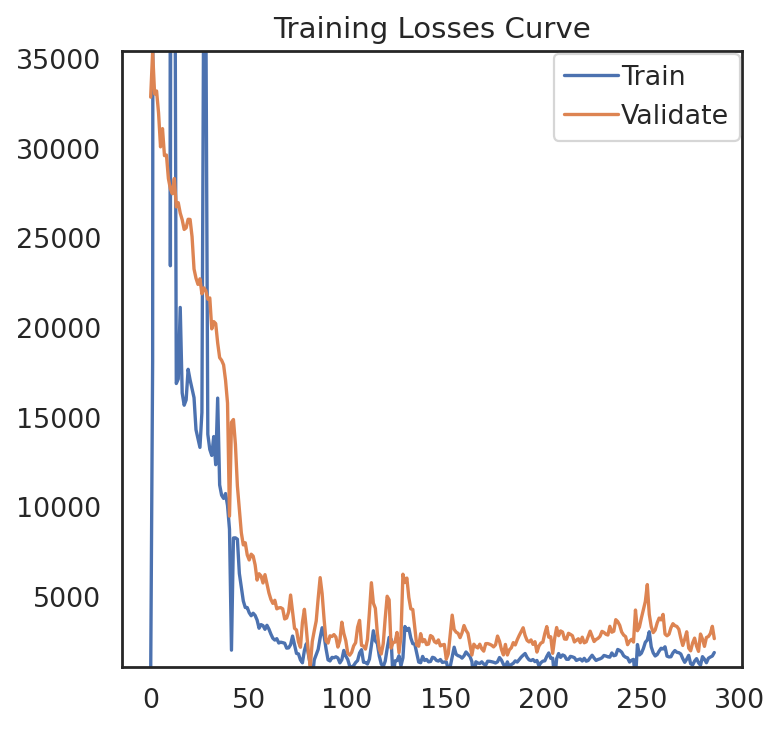

<Figure size 400x400 with 0 Axes>

In [17]:
trainer.plot_losses_curve()

In [18]:
adata_final = trainer.get_latent_representation()
adata_final

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 5180 × 13933
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch', 'n_genes'
    var: 'gene-0', 'n_cells-0', 'chr-1', 'start-1', 'end-1', 'symbol-1', 'strand-1'
    uns: 'neighbors'
    obsm: 'X_gf'
    obsp: 'distances', 'connectivities'

In [18]:
import torch
tmp = torch.load('/data2/zhouwg_data/project/Garfield/result_garfield_multiome_10xpbmc3k_Unpaired/multiome_10xpbmc3k_processed/multiome_10xpbmc3k_merged_adata.pt')
tmp

AnnData object with n_obs × n_vars = 5180 × 13000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA_snn_res.1', 'seurat_clusters', 'celltype', 'RNA.weight', 'peaks.weight', 'batch', 'n_genes'
    obsm: 'X_pca', 'X_lsi'
    layers: 'counts'
    obsp: 'connectivities'

In [19]:
len(tmp.obsp['connectivities'].data)

6696

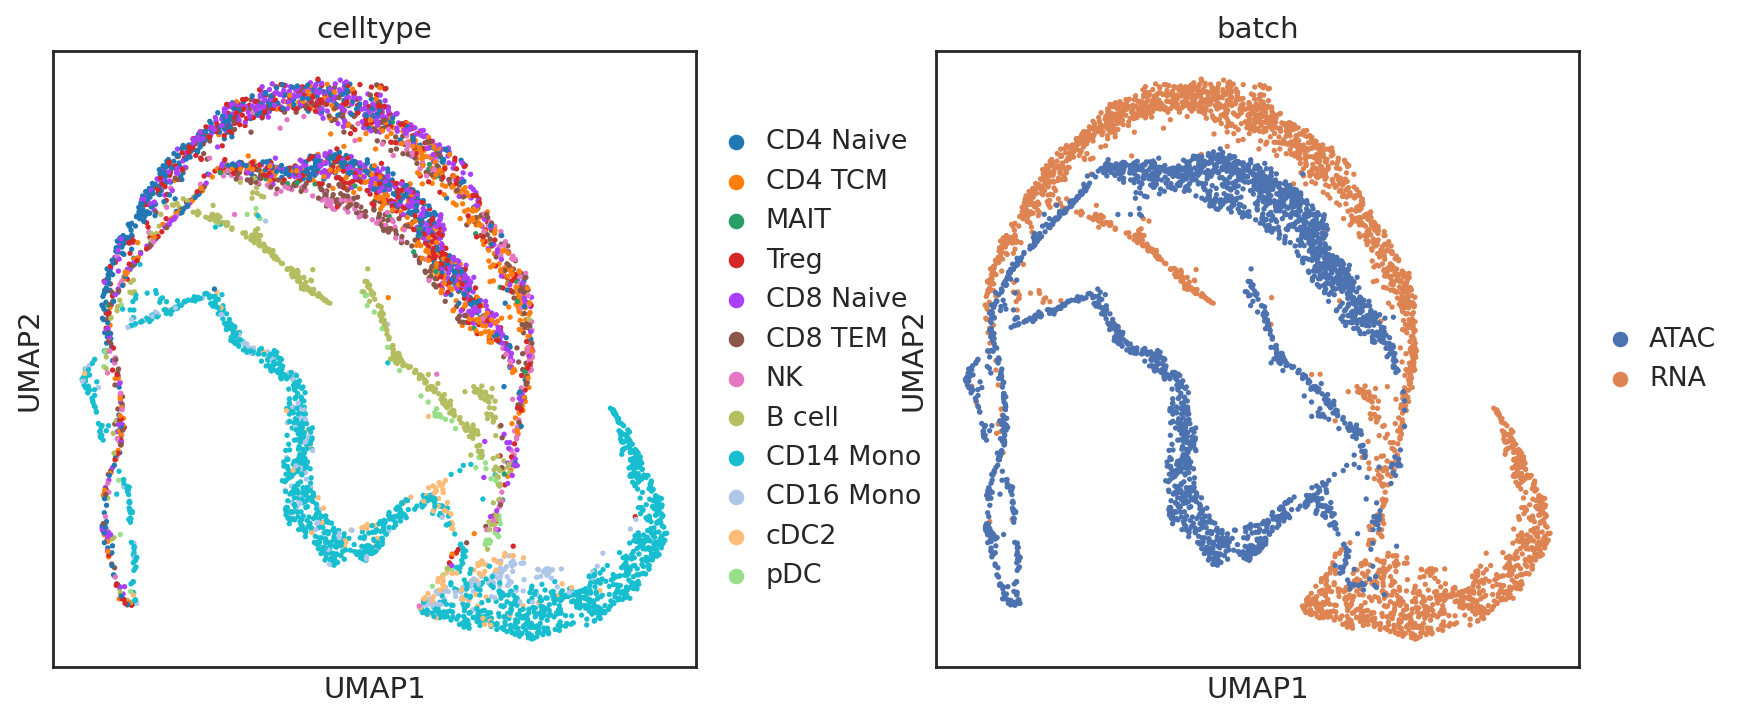

In [19]:
sc.tl.umap(adata_final)
# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['celltype','batch'], wspace=0.25, edges=False)

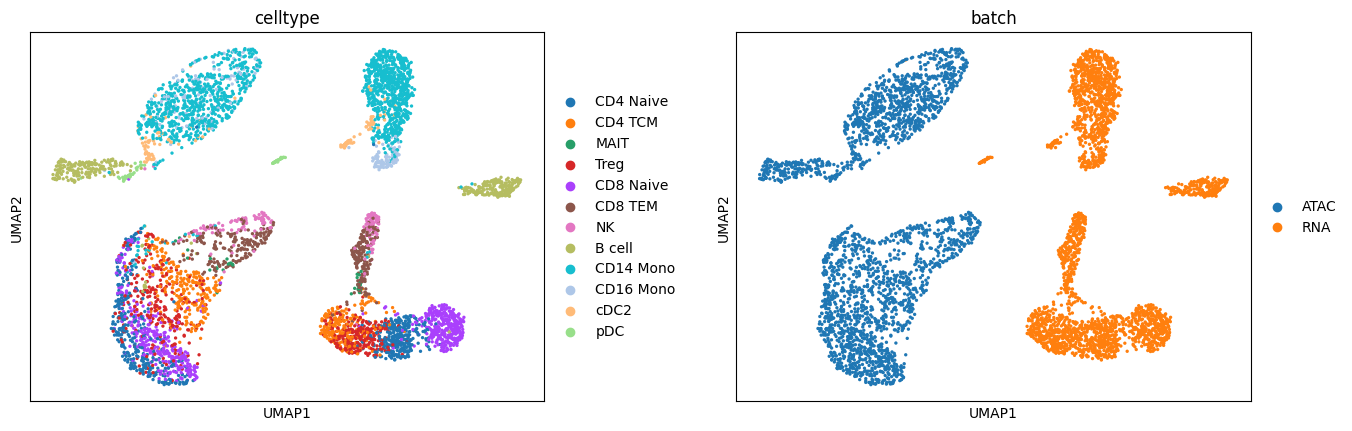

In [21]:
sc.tl.umap(adata_final)
# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['celltype','batch'], wspace=0.25, edges=False, save='_pbmc10x_unpaired-rna.pdf')

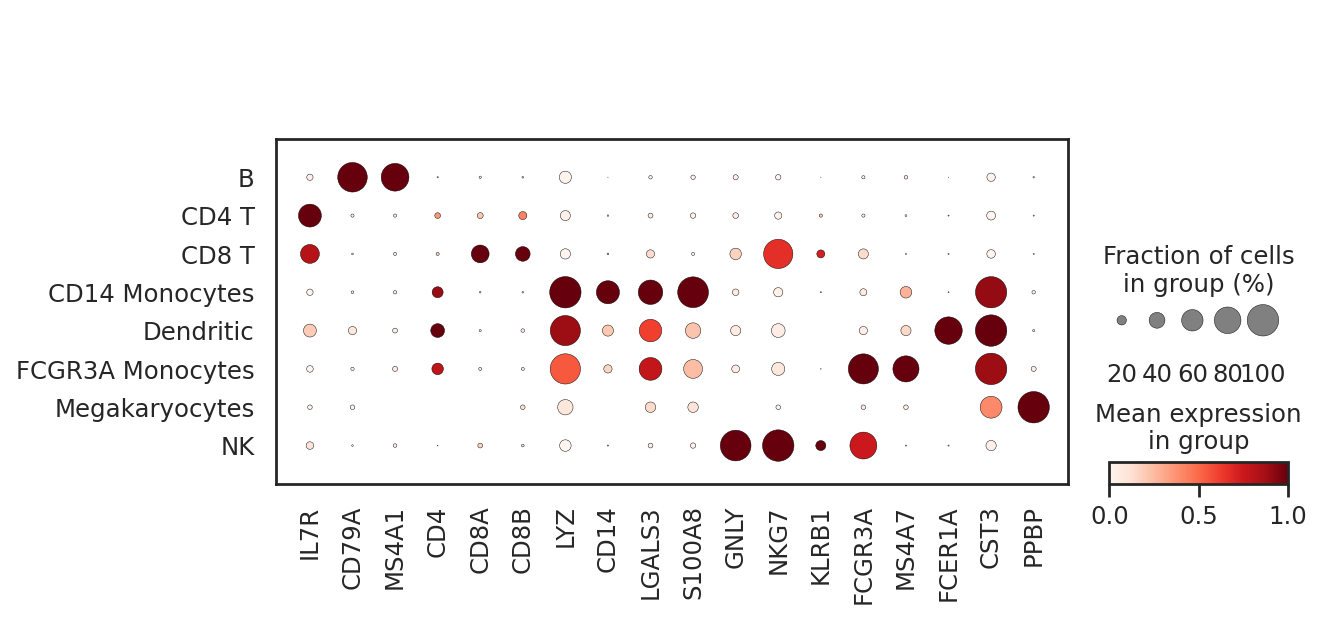

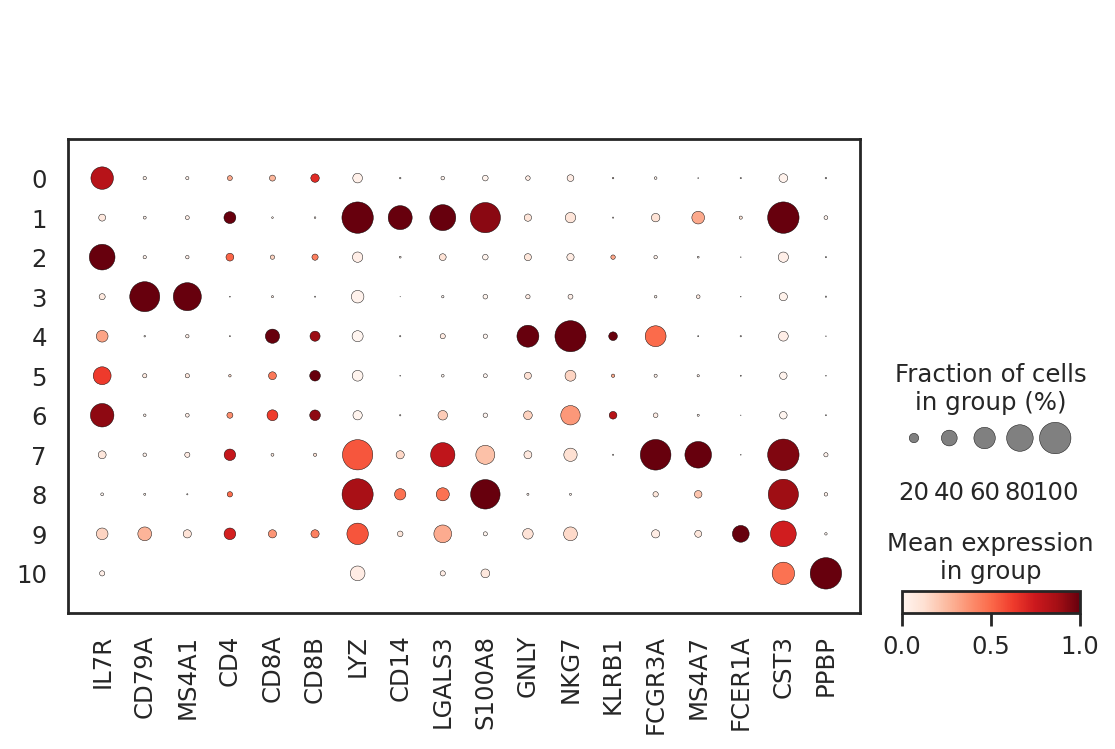

In [24]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD4", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]
sc.pl.dotplot(adata_final, marker_genes, groupby="celltype",standard_scale='var')
sc.pl.dotplot(adata_final, marker_genes, groupby="leiden", standard_scale='var');